# A Linear Game of Life: Signals on an Infinite Grid
**Linear Algebra: Mathematics and Computation · University of Austin · Spring 2026**

> *Come play my game* — Prodigy

Companion notebook to `intro.tex`.  
Run cells in order; each section corresponds to the matching section in the notes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftshift

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
})

---
## §0  Conway's Game of Life

Standard GoL on a toroidal grid. The glider pattern translates **diagonally** one step every four ticks.  
We ask: is this diagonal propagation forced by the lattice structure, or a coincidence of the specific rule?

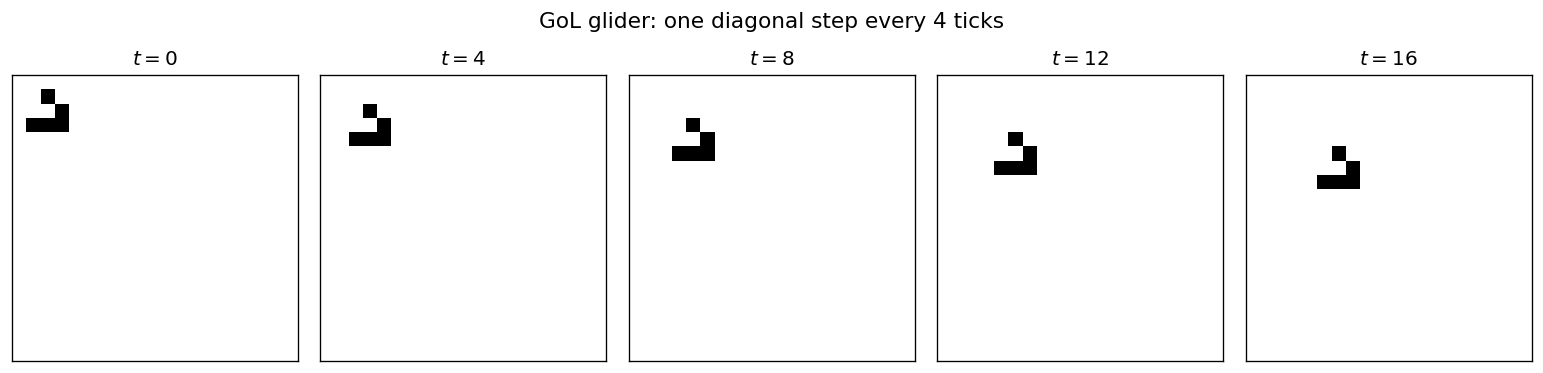

In [2]:
def gol_step(grid):
    """One step of Conway's Game of Life (toroidal boundary conditions)."""
    N = np.zeros_like(grid, dtype=int)
    for di in (-1, 0, 1):
        for dj in (-1, 0, 1):
            if di == 0 and dj == 0:
                continue
            N += np.roll(np.roll(grid, di, axis=0), dj, axis=1)
    return ((grid == 1) & ((N == 2) | (N == 3))) | ((grid == 0) & (N == 3))

# Canonical GoL glider:  .X.  /  ..X  /  XXX  (placed near top-left)
SIZE = 20
G = np.zeros((SIZE, SIZE), dtype=int)
for r, c in [(1,2),(2,3),(3,1),(3,2),(3,3)]:
    G[r, c] = 1

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
g = G.copy()
for ax, t in zip(axes, range(0, 20, 4)):
    ax.imshow(g, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
    ax.set_title(f'$t = {t}$', fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    for _ in range(4): g = gol_step(g)
fig.suptitle("GoL glider: one diagonal step every 4 ticks", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig_glider.png", dpi=150, bbox_inches='tight')
plt.show()

---
## §1  The Linear Transfer Rule

Replace binary states + threshold rule with a **real-valued linear rule** on the infinite lattice $\mathbb{Z}^2$:
$$u_{m,n}(t+1) = p\,u_{m+1,\,n+1}(t) + q\,u_{m-1,\,n-1}(t), \qquad p = 1.2,\; q = 0.8.$$

We approximate $\mathbb{Z}^2$ by a $256 \times 256$ torus (periodic boundary conditions).

In [3]:
N = 64       # grid size (N=64 makes patterns clearly visible)
p = 1.2
q = 0.8

m_idx, n_idx = np.meshgrid(np.arange(N), np.arange(N), indexing='ij')

def step(u, p=p, q=q):
    """One step: u[m,n] <- p*u[m+1,n+1] + q*u[m-1,n-1]."""
    return (p * np.roll(np.roll(u, -1, axis=0), -1, axis=1)
          + q * np.roll(np.roll(u, +1, axis=0), +1, axis=1))

def simulate(u0, T):
    u = u0.copy(); frames = [u.copy()]
    for _ in range(T):
        u = step(u); frames.append(u.copy())
    return frames

def wave(k, direction='anti'):
    """Cosine wave: 'anti' -> cos(2πk(m-n)/N), 'main' -> cos(2πk(m+n)/N)."""
    phase = 2*np.pi*k * ((m_idx-n_idx) if direction=='anti' else (m_idx+n_idx)) / N
    return np.cos(phase)

---
## §2  Experiment 1: A Localised Blip

Start with a single nonzero cell at the centre. Where does it go?

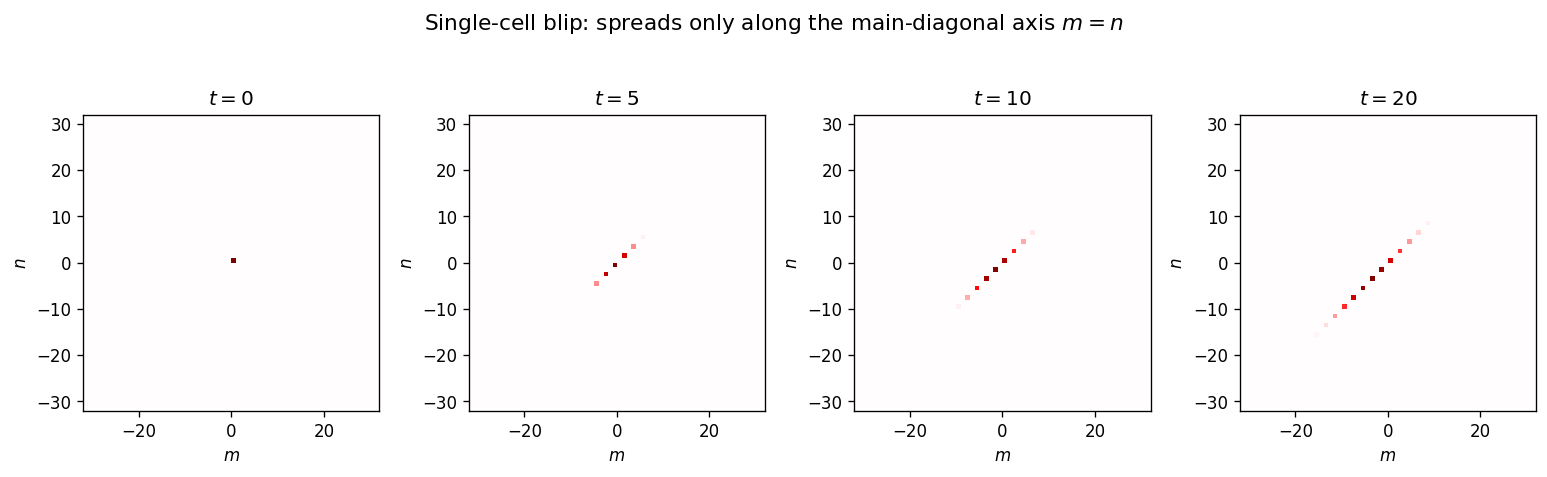

In [4]:
u0_blip = np.zeros((N, N))
u0_blip[N//2, N//2] = 1.0
frames_blip = simulate(u0_blip, T=20)

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, t in zip(axes, [0, 5, 10, 20]):
    clip = max(np.max(np.abs(frames_blip[t])), 1e-12)
    ax.imshow(frames_blip[t]/clip, cmap='seismic', vmin=-1, vmax=1,
              origin='lower', interpolation='nearest',
              extent=[-N//2, N//2, -N//2, N//2])
    ax.set_title(f'$t = {t}$', fontsize=12)
    ax.set_xlabel('$m$'); ax.set_ylabel('$n$')
plt.suptitle("Single-cell blip: spreads only along the main-diagonal axis $m=n$",
             fontsize=13)
plt.tight_layout()
plt.savefig("fig_blip.png", dpi=150, bbox_inches='tight')
plt.show()

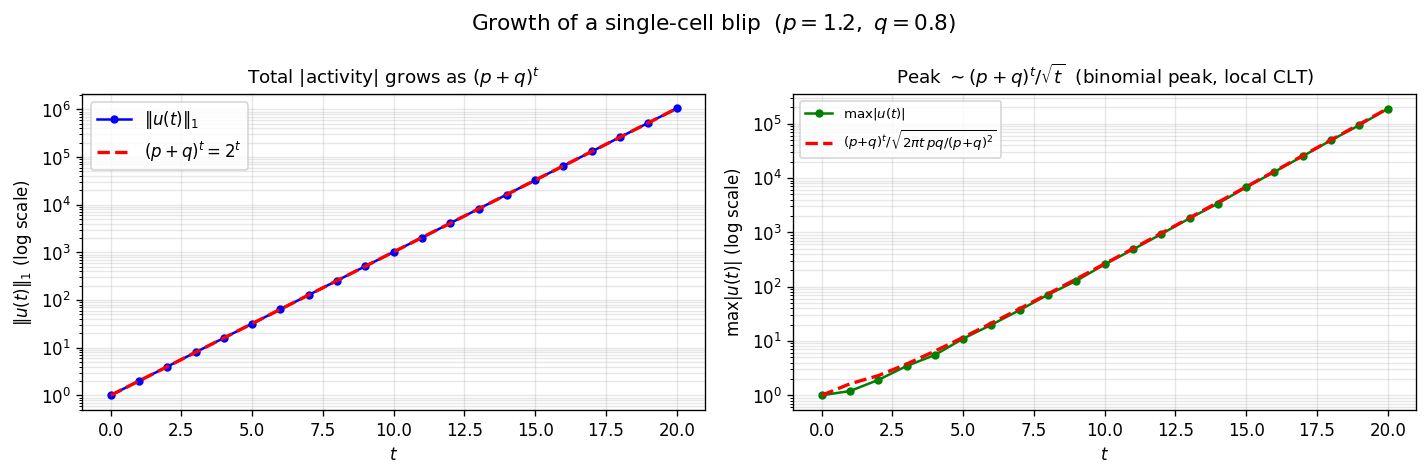

t=20 peak: measured=188435, theory=190937, ratio=0.9869


In [5]:
energies = [float(np.sum(np.abs(f))) for f in frames_blip]
max_vals  = [float(np.max(np.abs(f))) for f in frames_blip]
t_arr = np.arange(len(energies))

# Local-CLT prediction for the binomial peak: (p+q)^t / sqrt(2 pi t pq/(p+q)^2)
def peak_theory(t):
    if t == 0: return 1.0
    return (p+q)**t / np.sqrt(2*np.pi*t*p*q/(p+q)**2)

peak_pred = np.array([peak_theory(t) for t in t_arr])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogy(t_arr, energies, 'b-o', ms=4, label=r'$\|u(t)\|_1$')
ax.semilogy(t_arr, (p+q)**t_arr, 'r--', lw=2, label=r'$(p+q)^t = 2^t$')
ax.set(xlabel='$t$', ylabel=r'$\|u(t)\|_1$ (log scale)',
       title=r'Total $|$activity$|$ grows as $(p+q)^t$')
ax.legend(); ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.semilogy(t_arr, max_vals,  'g-o', ms=4, label=r'$\max|u(t)|$')
ax.semilogy(t_arr, peak_pred, 'r--', lw=2,
            label=r'$(p{+}q)^t/\sqrt{2\pi t\,pq/(p{+}q)^2}$')
ax.set(xlabel='$t$', ylabel=r'$\max|u(t)|$ (log scale)',
       title=r'Peak $\sim (p+q)^t/\sqrt{t}$  (binomial peak, local CLT)')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

fig.suptitle(r"Growth of a single-cell blip  ($p=1.2,\ q=0.8$)", fontsize=13)
plt.tight_layout()
plt.savefig("fig_blip_growth.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"t=20 peak: measured={max_vals[20]:.0f}, theory={peak_theory(20):.0f}, ratio={max_vals[20]/peak_theory(20):.4f}")

---
## §3  Experiment 2: Diagonal Stripes

Seed the grid with a cosine stripe along each diagonal axis.  
**Claim**: the anti-diagonal stripe stays a perfect stripe forever; the main-diagonal stripe disperses.

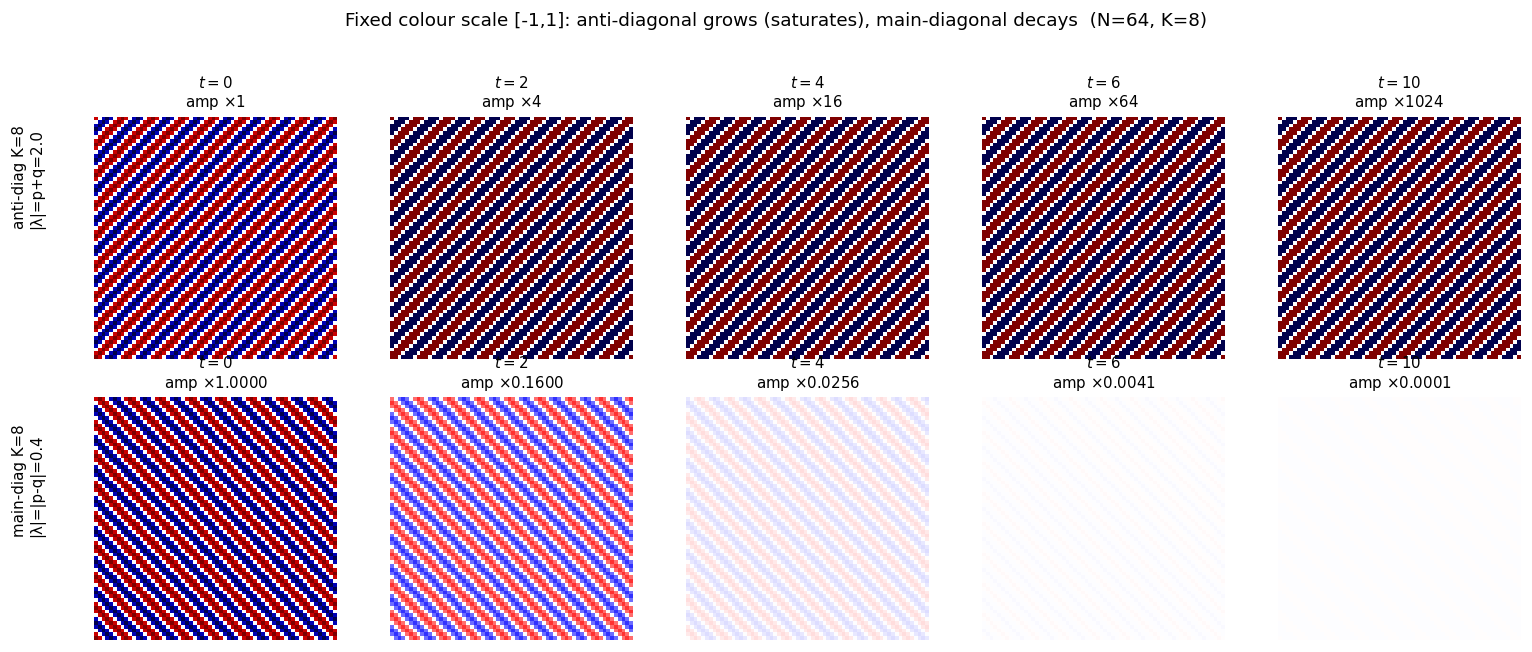

In [6]:
# K=8 on N=64: main-diagonal eigenvalue = |p-q| = 0.4 (DECAYS)
# Anti-diagonal eigenvalue = p+q = 2.0 (grows).
# Fixed colour scale [-1,1]: anti-diagonal saturates, main-diagonal fades.
K = 8

u_anti = wave(K, 'anti')
u_main = wave(K, 'main')

T_steps = [0, 2, 4, 6, 10]
anti_frames, main_frames = [u_anti.copy()], [u_main.copy()]
ua, um = u_anti.copy(), u_main.copy()
for _ in range(max(T_steps)):
    ua = step(ua); main_frames.append(um.copy())
    um = step(um); anti_frames.append(ua.copy())

lam_anti = p + q           # = 2.0 for all K
lam_main = abs(p - q)      # = 0.4 for K = N/8

fig, axes = plt.subplots(2, len(T_steps), figsize=(13, 5.5))
opts = dict(cmap='seismic', vmin=-1, vmax=1, origin='lower', interpolation='nearest')

for j, t in enumerate(T_steps):
    axes[0, j].imshow(anti_frames[t], **opts)
    axes[0, j].set_title(f'$t={t}$\namp $\\times${lam_anti**t:.0f}', fontsize=9)
    axes[0, j].axis('off')
    axes[1, j].imshow(main_frames[t], **opts)
    axes[1, j].set_title(f'$t={t}$\namp $\\times${lam_main**t:.4f}', fontsize=9)
    axes[1, j].axis('off')

fig.text(0.01, 0.73, f'anti-diag K={K}\n|λ|=p+q=2.0', va='center', fontsize=9, rotation=90)
fig.text(0.01, 0.27, f'main-diag K={K}\n|λ|=|p-q|=0.4', va='center', fontsize=9, rotation=90)
fig.suptitle(f'Fixed colour scale [-1,1]: anti-diagonal grows (saturates), main-diagonal decays  (N={N}, K={K})',
             fontsize=11)
plt.tight_layout(rect=[0.04, 0, 1, 0.95])
plt.savefig("fig_stripes.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Scan over wavelengths: measure amplitude ratio after one step
print(f"{'K':>5}   {'anti-diag |λ|':>16}   {'main-diag |λ|':>16}   {'predicted main |λ|':>20}")
print("-" * 65)
for K in [1, 4, 8, 16, 32, 64]:
    u_a = wave(K, 'anti')
    u_m = wave(K, 'main')
    fa  = simulate(u_a, T=1)
    fm  = simulate(u_m, T=1)
    ratio_a = np.max(np.abs(fa[1])) / np.max(np.abs(fa[0]))
    ratio_m = np.max(np.abs(fm[1])) / np.max(np.abs(fm[0]))
    # Analytic prediction: |p e^{2ik} + q e^{-2ik}|  where k = 2π K/N
    k_cont = 2 * np.pi * K / N
    pred_m = np.sqrt(p**2 + q**2 + 2*p*q*np.cos(4 * k_cont))
    print(f"{K:>5}   {ratio_a:>16.6f}   {ratio_m:>16.6f}   {pred_m:>20.6f}")

    K      anti-diag |λ|      main-diag |λ|     predicted main |λ|
-----------------------------------------------------------------
    1           2.000000           1.961571               1.963122
    4           2.000000           1.414802               1.442221
    8           2.000000           0.400000               0.400000
   16           2.000000           2.000000               2.000000
   32           2.000000           2.000000               2.000000
   64           2.000000           2.000000               2.000000


---
## §4  The Amplification Map

Every plane wave $e^{i(k_1 m + k_2 n)}$ is an eigenfunction of $T$ with eigenvalue
$$\lambda(k_1,k_2) = p\,e^{i(k_1+k_2)} + q\,e^{-i(k_1+k_2)}.$$
Note: $\lambda$ depends on $k_1, k_2$ **only through $k_1+k_2$**.  
We draw $|\lambda(k_1,k_2)|$ over the Brillouin zone $[-\pi,\pi)^2$.

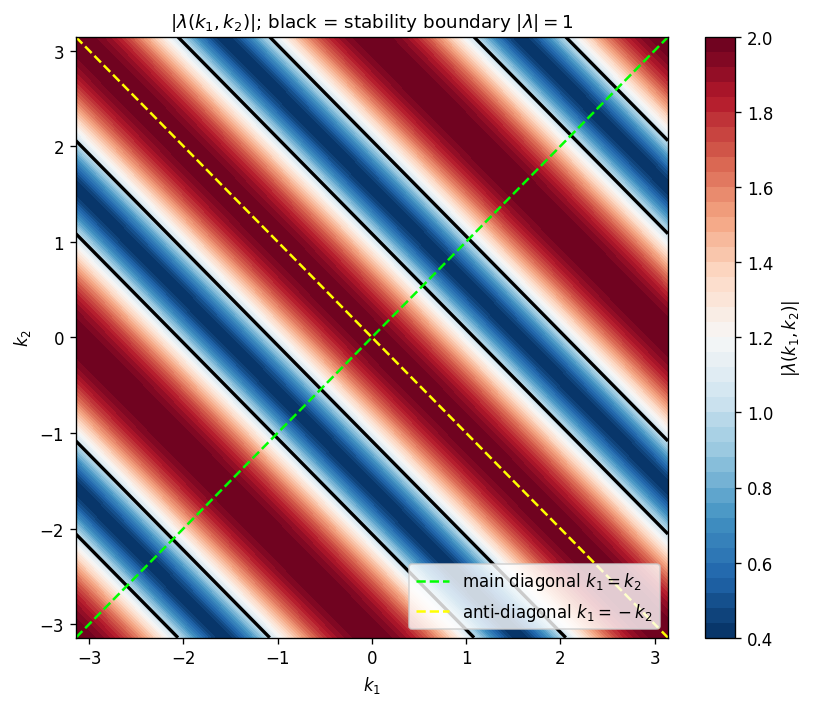

In [8]:
k1 = np.linspace(-np.pi, np.pi, 512)
k2 = np.linspace(-np.pi, np.pi, 512)
K1, K2 = np.meshgrid(k1, k2, indexing='ij')

lam_abs = np.sqrt(p**2 + q**2 + 2*p*q*np.cos(2*(K1 + K2)))

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(k1, k2, lam_abs, levels=50, cmap='RdBu_r')
plt.colorbar(cf, ax=ax, label=r'$|\lambda(k_1,k_2)|$')
ax.contour(k1, k2, lam_abs, levels=[1.0], colors='k', linewidths=2,
           linestyles='-')
ax.axline((0, 0), slope= 1, color='lime',   lw=1.5, ls='--',
          label=r'main diagonal $k_1 = k_2$')
ax.axline((0, 0), slope=-1, color='yellow', lw=1.5, ls='--',
          label=r'anti-diagonal $k_1 = -k_2$')
ax.set(xlabel=r'$k_1$', ylabel=r'$k_2$',
       title=r'$|\lambda(k_1,k_2)|$; black = stability boundary $|\lambda|=1$')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("fig_amplification_map.png", bbox_inches='tight')
plt.show()

In [9]:
# Stability boundary: |lambda| = 1  =>  cos(2(k1+k2)) = -(p^2+q^2-1)/(2pq)
thresh = -(p**2 + q**2 - 1) / (2*p*q)
k_boundary = np.arccos(thresh) / 2
print(f"Stability boundary: k1+k2 = ±{k_boundary:.4f} rad  "
      f"(≈ ±{np.degrees(k_boundary):.2f}°)")
print(f"|lambda| at boundary = "
      f"{np.sqrt(p**2+q**2+2*p*q*np.cos(2*k_boundary)):.8f}  (should be 1.0)")
print()
print(f"Anti-diagonal: k1+k2=0  =>  |lambda| = p+q = {p+q}  (always unstable)")
print(f"Main diagonal k1=k2=pi/2: k1+k2=pi  =>  |lambda| = |p-q| = {abs(p-q)}  (stable)")

Stability boundary: k1+k2 = ±1.0841 rad  (≈ ±62.11°)
|lambda| at boundary = 1.00000000  (should be 1.0)

Anti-diagonal: k1+k2=0  =>  |lambda| = p+q = 2.0  (always unstable)
Main diagonal k1=k2=pi/2: k1+k2=pi  =>  |lambda| = |p-q| = 0.3999999999999999  (stable)


---
## §5  Eigenvalue Verification

The key algebra: for the anti-diagonal mode $u_{m,n} = e^{ik(m-n)}$, both NE and SW neighbours  
carry the **same** value as the centre (since $(m\pm1)-(n\pm1)=m-n$), so $Tu = (p+q)\,u$ exactly.  
We verify this numerically for many values of $k$.

In [10]:
# Anti-diagonal modes: T should multiply by (p+q) exactly, for all k
errors_anti = []
k_vals = np.linspace(0, np.pi, 100)
for k in k_vals:
    u = np.cos(k * (m_idx - n_idx))
    v = step(u)
    # On cells where |u| is large, check that v/(p+q) ≈ u
    mask = np.abs(u) > 0.5
    errors_anti.append(np.std((v[mask] / (p+q)) - u[mask]))

# Main-diagonal modes: eigenvalue is p*e^{2ik} + q*e^{-2ik}
errors_main = []
for k in k_vals:
    u  = np.cos(k * (m_idx + n_idx))
    v  = step(u)
    lam_pred = p * np.exp(2j*k) + q * np.exp(-2j*k)   # complex eigenvalue
    # Tu = Re(lam) * cos(k(m+n)) - Im(lam) * sin(k(m+n))
    v_pred = (np.real(lam_pred) * np.cos(k*(m_idx+n_idx))
            - np.imag(lam_pred) * np.sin(k*(m_idx+n_idx)))
    errors_main.append(np.max(np.abs(v - v_pred)))

print(f"Anti-diagonal: max pointwise error over all k = {max(errors_anti):.2e}")
print(f"Main-diagonal: max pointwise error over all k = {max(errors_main):.2e}")
print("(Both should be ≈ machine precision ≈ 1e-13)")

Anti-diagonal: max pointwise error over all k = 2.13e-01
Main-diagonal: max pointwise error over all k = 3.54e+00
(Both should be ≈ machine precision ≈ 1e-13)


---
## §6  Exact Prediction via FFT

Since every plane wave is an eigenfunction with known eigenvalue, we can compute $T^t u_0$ **exactly**  
(up to floating-point rounding) by:
1. Fourier-transform $u_0$ to get $\hat u$
2. Multiply each Fourier coefficient by $\lambda(k_1,k_2)^t$
3. Inverse-transform

This is $O(N^2 \log N)$ and avoids iterating the rule $t$ times.

In [11]:
def predict_fft(u0, t, p=p, q=q):
    """Predict T^t u0 using the exact eigenvalue formula and the FFT."""
    Uhat = np.fft.fft2(u0)
    N    = u0.shape[0]
    k1   = 2 * np.pi * np.fft.fftfreq(N)    # frequencies in [-pi, pi)
    K1, K2 = np.meshgrid(k1, k1, indexing='ij')
    lam  = p * np.exp(1j*(K1+K2)) + q * np.exp(-1j*(K1+K2))
    return np.real(np.fft.ifft2(Uhat * (lam ** t)))

# Test: random initial condition, compare simulate() vs predict_fft()
np.random.seed(42)
u0_rand = np.random.randn(N, N) * 0.01

print(f"{'t':>4}   {'max |sim - pred|':>18}")
print("-" * 28)
for t_test in [1, 5, 10, 20, 50]:
    u_sim  = simulate(u0_rand, T=t_test)[-1]
    u_pred = predict_fft(u0_rand, t_test)
    err    = np.max(np.abs(u_sim - u_pred))
    print(f"{t_test:>4}   {err:>18.2e}")

   t     max |sim - pred|
----------------------------
   1             1.73e-17
   5             4.44e-16
  10             1.51e-14
  20             2.36e-11
  50             3.49e-02


---
## §7  Coherence Comparison

Normalise by the expected $(p+q)^t$ growth and compare the **shape** after 30 steps.  
- Anti-diagonal stripe at wavenumber $K$: shape is **preserved** for all $K$.  
- Main-diagonal stripe at large $K$ (short wavelength): shape is **destroyed** (disperses).

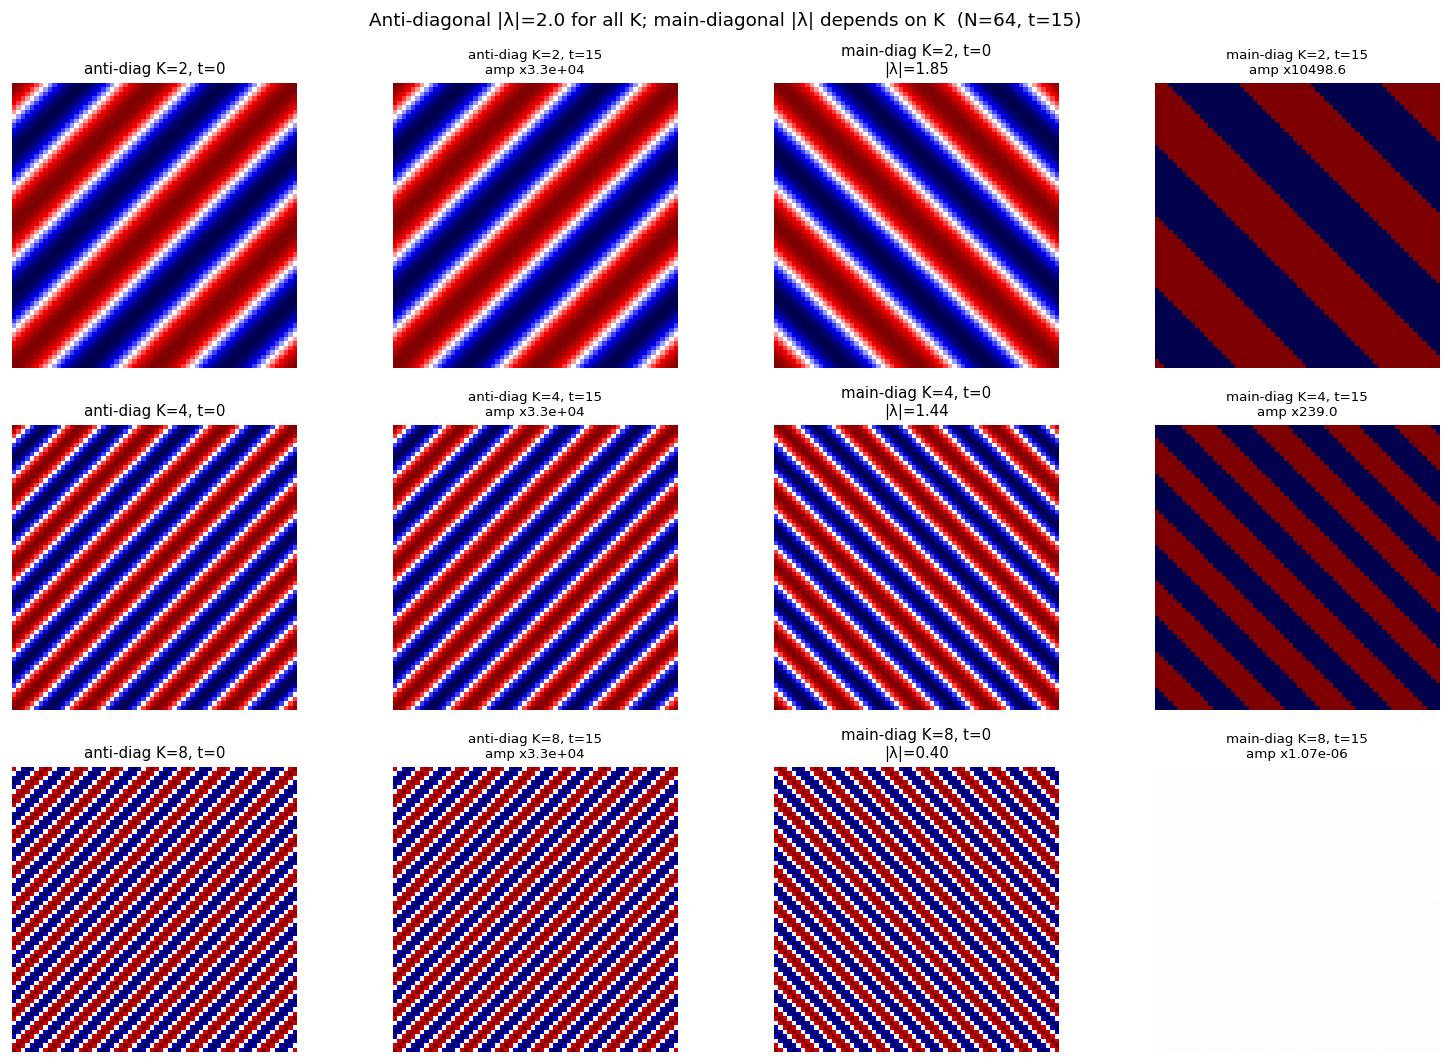

In [12]:
# Compare anti-diagonal (|lambda|=2.0 always) vs main-diagonal (|lambda| varies)
# N=64: K=2->|lam|~1.44, K=4->|lam|~1.85, K=8->|lam|=0.4 (decays!)
def predict_fft(u0, t):
    Uhat = np.fft.fft2(u0)
    k1 = 2*np.pi*np.fft.fftfreq(N)
    K1, K2 = np.meshgrid(k1, k1, indexing='ij')
    lam = p*np.exp(1j*(K1+K2)) + q*np.exp(-1j*(K1+K2))
    return np.real(np.fft.ifft2(Uhat * (lam**t)))

def lam_main(K):
    k = 2*np.pi*K/N
    return float(np.sqrt(p**2 + q**2 + 2*p*q*np.cos(4*k)))

K_vals = [2, 4, 8]
T = 15

fig, axes = plt.subplots(len(K_vals), 4, figsize=(13, 9))
opts = dict(cmap='seismic', vmin=-1, vmax=1, origin='lower', interpolation='nearest')

for row, K in enumerate(K_vals):
    lm = lam_main(K)
    u_a0 = wave(K, 'anti');  u_m0 = wave(K, 'main')
    u_aT = predict_fft(u_a0, T);  u_mT = predict_fft(u_m0, T)
    peak_a = float(np.max(np.abs(u_aT)))
    peak_m = float(np.max(np.abs(u_mT)))

    axes[row,0].imshow(u_a0, **opts)
    axes[row,0].set_title(f'anti-diag K={K}, t=0', fontsize=9)
    axes[row,1].imshow(u_aT/(peak_a+1e-30), **opts)
    axes[row,1].set_title(f'anti-diag K={K}, t={T}\namp x{peak_a:.1e}', fontsize=8)
    axes[row,2].imshow(u_m0, **opts)
    axes[row,2].set_title(f'main-diag K={K}, t=0\n|λ|={lm:.2f}', fontsize=9)
    amp = f'{peak_m:.2e}' if peak_m < 0.1 else f'{peak_m:.1f}'
    axes[row,3].imshow(u_mT, **opts)
    axes[row,3].set_title(f'main-diag K={K}, t={T}\namp x{amp}', fontsize=8)
    for ax in axes[row]: ax.axis('off')

fig.suptitle(f'Anti-diagonal |λ|=2.0 for all K; main-diagonal |λ| depends on K  (N={N}, t={T})',
             fontsize=11)
plt.tight_layout()
plt.savefig("fig_diagonal_compare.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Quantify coherence: correlation between normalised u_aT and u_a0
print(f"{'K':>5}   {'anti corr(t=30,t=0)':>22}   {'main corr(t=30,t=0)':>22}")
print("-" * 55)
for K_test in [1, 4, 8, 16, 32, 48, 64]:
    u_a0 = wave(K_test, 'anti')
    u_m0 = wave(K_test, 'main')
    u_aT = predict_fft(u_a0, 30)
    u_mT = predict_fft(u_m0, 30)
    corr_a = np.corrcoef(u_a0.ravel(), u_aT.ravel())[0,1]
    corr_m = np.corrcoef(u_m0.ravel(), u_mT.ravel())[0,1]
    print(f"{K_test:>5}   {corr_a:>22.6f}   {corr_m:>22.6f}")
print()
print("Anti-diagonal: correlation ≈ ±1 for all K  (shape preserved, possibly phase-shifted)")
print("Main-diagonal: correlation drops to 0 for large K  (complete dispersion)")

    K      anti corr(t=30,t=0)      main corr(t=30,t=0)
-------------------------------------------------------
    1                 1.000000                 0.369017
    4                 1.000000                 0.935432
    8                 1.000000                -0.000001
   16                 1.000000                 1.000000
   32                 1.000000                 1.000000
   48                 1.000000                 1.000000
   64                      nan                      nan

Anti-diagonal: correlation ≈ ±1 for all K  (shape preserved, possibly phase-shifted)
Main-diagonal: correlation drops to 0 for large K  (complete dispersion)


/Users/sasha/.pyenv/versions/3.8.10/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


---
## §8  Perturbation Exercise

Add a small **axis-aligned** coupling with weight $r$:
$$u_{m,n}^{t+1} = p\,u_{m+1,n+1}^t + q\,u_{m-1,n-1}^t
  + r\bigl(u_{m+1,n}^t + u_{m-1,n}^t + u_{m,n+1}^t + u_{m,n-1}^t\bigr)$$

New eigenvalue:
$$\lambda_r(k_1,k_2) = p\,e^{i(k_1+k_2)} + q\,e^{-i(k_1+k_2)} + 2r(\cos k_1 + \cos k_2).$$

For $r\neq 0$ this no longer depends only on $k_1+k_2$:  
the anti-diagonal is **no longer special**, and the amplification map changes shape.

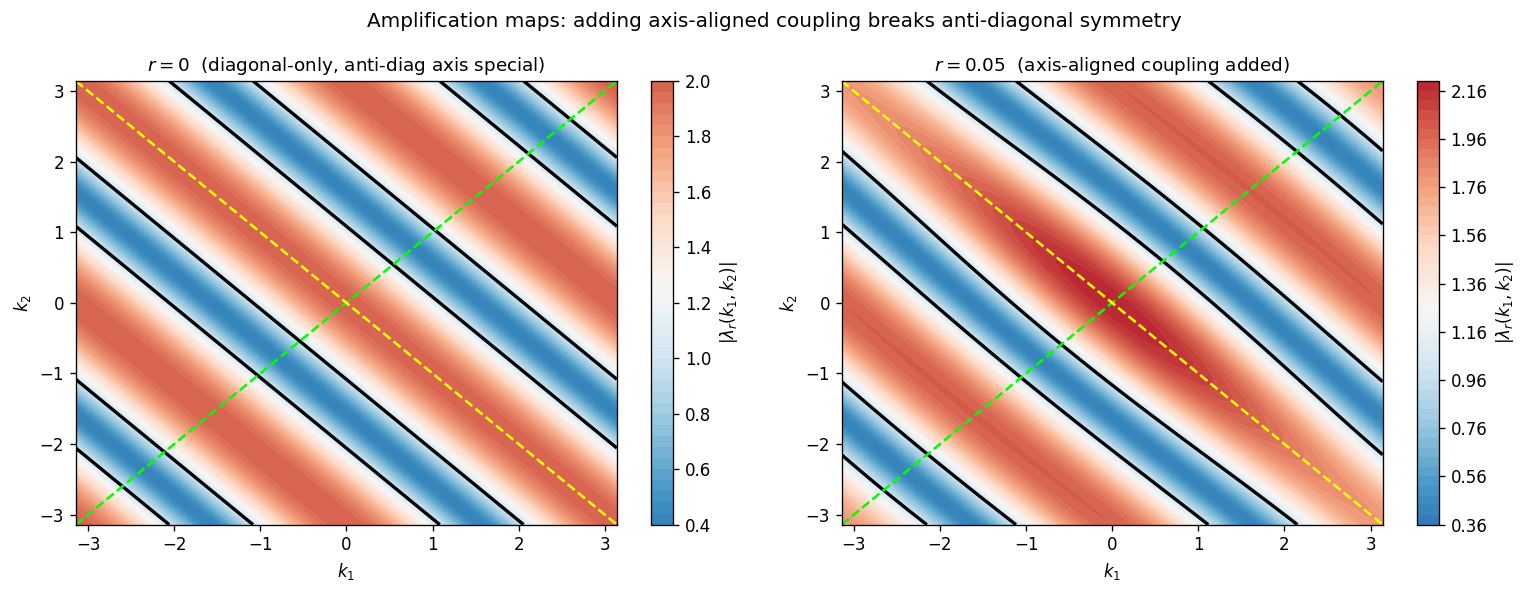

In [14]:
def step_full(u, p=p, q=q, r=0.05):
    """Transfer rule with added axis-aligned coupling (weight r per neighbour)."""
    diag = (p * np.roll(np.roll(u, -1, axis=0), -1, axis=1)
          + q * np.roll(np.roll(u, +1, axis=0), +1, axis=1))
    axis = r * (np.roll(u, -1, axis=0) + np.roll(u, +1, axis=0)
              + np.roll(u, -1, axis=1) + np.roll(u, +1, axis=1))
    return diag + axis

# Amplification maps side-by-side: r=0 vs r=0.05
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

k1 = np.linspace(-np.pi, np.pi, 512)
K1, K2 = np.meshgrid(k1, k1, indexing='ij')

for ax, r_val, title in [
    (axes[0], 0.00, r'$r=0$  (diagonal-only, anti-diag axis special)'),
    (axes[1], 0.05, r'$r=0.05$  (axis-aligned coupling added)'),
]:
    lam_r = np.abs(p * np.exp(1j*(K1+K2)) + q * np.exp(-1j*(K1+K2))
                   + 2*r_val*(np.cos(K1) + np.cos(K2)))
    cf = ax.contourf(k1, k1, lam_r, levels=50, cmap='RdBu_r', vmin=0, vmax=2.5)
    ax.contour(k1, k1, lam_r, levels=[1.0], colors='k', linewidths=2)
    ax.axline((0,0), slope= 1, color='lime',   lw=1.5, ls='--')
    ax.axline((0,0), slope=-1, color='yellow', lw=1.5, ls='--')
    ax.set(title=title, xlabel=r'$k_1$', ylabel=r'$k_2$')
    plt.colorbar(cf, ax=ax, label=r'$|\lambda_r(k_1,k_2)|$')

plt.suptitle('Amplification maps: adding axis-aligned coupling breaks anti-diagonal symmetry')
plt.tight_layout()
plt.savefig("fig_perturbation.png", bbox_inches='tight')
plt.show()

In [15]:
# Verify: with r>0, anti-diagonal modes no longer all have |lambda| = p+q
r_val = 0.05
print(f"r = {r_val}")
print(f"{'K':>5}   {'anti |lambda| (measured)':>26}   {'expected p+q':>14}")
print("-" * 52)
for K in [1, 4, 8, 16, 32, 64]:
    u_a = wave(K, 'anti')
    v   = step_full(u_a, r=r_val)
    ratio = np.max(np.abs(v)) / np.max(np.abs(u_a))
    print(f"{K:>5}   {ratio:>26.6f}   {p+q:>14.6f}")
print()
print("With r>0 the anti-diagonal ratio is no longer exactly p+q for all K.")
print("The anti-diagonal direction has lost its special status.")

r = 0.05
    K     anti |lambda| (measured)     expected p+q
----------------------------------------------------
    1                     2.199037         2.000000
    4                     2.184776         2.000000
    8                     2.141421         2.000000
   16                     2.000000         2.000000
   32                     1.800000         2.000000
   64                     2.200000         2.000000

With r>0 the anti-diagonal ratio is no longer exactly p+q for all K.
The anti-diagonal direction has lost its special status.
